# Beyond BLAST

In [1]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 

using Base.Threads, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON;

[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   2004.2 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-ea30-2282-413c-d1145759f751 is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    570.9 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompiling FastChebInterp [cf66c380-9a80-432c-aff8-4f9c79c0bdde]
Precompi

In [98]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
using .Blast
using .blast_tutorials

include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
using .galaxy_galaxy
using .shear_shear

In [3]:
timestamp = Dates.format(now(), "yyyy_mm_dd_HHMMSS")
output_dir = "out/runs/run_$timestamp"
plot_subdir = joinpath(output_dir, "plots")
Sl_plots = joinpath(plot_subdir, "Sl_plots")
Kernel_plots = joinpath(plot_subdir, "kernels")
quantity_subdir = joinpath(output_dir, "quantities")
chebcoefs = joinpath(quantity_subdir, "chebcoefs")
Sl = joinpath(quantity_subdir, "Sl")
mkpath(output_dir)
mkpath(plot_subdir)
mkpath(quantity_subdir)
mkpath(chebcoefs)
mkpath(Sl)
mkpath(Sl_plots)
mkpath(Kernel_plots)
println("Folders in place: ", output_dir, ", ", plot_subdir, " and ", quantity_subdir)

Folders in place: out/runs/run_2026_06_29_131013, out/runs/run_2026_06_29_131013/plots and out/runs/run_2026_06_29_131013/quantities


### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [99]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

#### Setting parameters

In [141]:
cosmo = Blast.FlatΛCDM()
n_chi = 110                                           # Number of comoving distance points
x_range = LinRange(26, 7000, n_chi)                   # in Mpc/h: from 26 Mpc/h to 7000 Mpc/h
z_range = z_of_χ.(x_range)
#ℓ = Blast.ℓ
ℓ = LinRange(2, 200, 100)
x_min = minimum(x_range)                              # minimum comoving distance [Mpc/h]
x_max = maximum(x_range)                              # maximum comoving distance [Mpc/h]
chi = LinRange(x_min, x_max, n_chi)                   # array of comoving distances [Mpc/h]
zed = z_of_χ.(chi)                                    # array of redshifts corresponding to the comoving distances
n_z = length(zed)
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
zmin = minimum(z_n5k)                                 # minimum redshift
zmax = maximum(z_n5k)                                 # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales) [h/Mpc]
kmin = 2.5/x_max                                      # minimum wavenumber (large scales) [h/Mpc]
n_cheb = 120                                         # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^15+1
Nz = n_chi
Nk = Nz
Nkp = Nz-20
Nkpp = Nz-20
k_grid = Blast.get_clencurt_grid(kmin, kmax, Nk)
kp_grid = Blast.get_clencurt_grid(kmin, kmax, Nkp)
kpp_grid = Blast.get_clencurt_grid(kmin, kmax, Nkpp);

In [128]:
shear_prefac_W = shear_shear.shear_prefactor(x_range, z_range, cosmo; output_dir=output_dir);
shear_prefac_W_cheb = shear_shear.shear_prefactor_cheb(zmin, zmax, n_cheb, z_range, shear_prefac_W; output_dir=output_dir);
cheb_coeff_shear = shear_shear.compute_prefactor_chebcoeffs(shear_prefac_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/chi_vs_z_shear.png
Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/nz_shear.png
Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/lensing_efficiency.png
Wrote W(z) shear prefactor on Chebyshev grid to: out/runs/run_2026_06_29_131013/quantities/prefac_on_cheb_shear.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_29_131013/quantities/W_cheb_coeff_shear.npy


Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = n(z) \chi(z)^2 b(z) D(z) $ \
\
where \
\
$n(z) = A (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, with $A = \frac{1.5}{z_0}$, $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, with $D(z)^{unnorm} = E(z) \int_z^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

As for the ````gal_prefactor_W_cheb````, it is obtained interpolating each factor, ````bias````, ````growth````, ````nz_norm````, ````chi```` on the ````z_range````, and then obtaining the total interpolated product ````gal_prefact_W_cheb````.

As for the ````cheb_coeff_gal````, I compute this similarly to Blast: I define a ````plan```` object that takes the ````gal_prefact_W_cheb```` as input, and then returns the ````cheb_coeff```` as the output of the functions ````fast_chebcoefs````

In [129]:
gal_prefact_W, bias, growth, inv_Hubble, nz_norm = galaxy_galaxy.galaxy_prefactor(x_range, z_range, cosmo; output_dir=output_dir);
gal_prefact_W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(zmin, zmax, n_cheb, z_range, chi, bias, growth, inv_Hubble, nz_norm; output_dir=output_dir);
cheb_coeff_gal = galaxy_galaxy.compute_prefactor_chebcoeffs(gal_prefact_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/chi_vs_z.png
Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/bias.png
Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/growth.png
Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/inv_hubble.png
Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/nz.png
Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/Wz.png
Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/normalized_kernel_galaxy.png
Plot saved: out/runs/run_2026_06_29_131013/plots/kernels/unnormalized_kernel_galaxy.png
Wrote W(z) prefactor to: out/runs/run_2026_06_29_131013/quantities/prefac_galaxy.npy
Wrote W(z) prefactor on Chebyshev grid to: out/runs/run_2026_06_29_131013/quantities/prefac_on_cheb_galaxy.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_29_131013/quantities/W_cheb_coeff_galaxy.npy


In [130]:
println("Size of cheb_coeffs must be the same for shear and galaxy")
println("size of cheb_coeff_shear: ", size(cheb_coeff_shear))
println("size of cheb_coeff_gal: ", size(cheb_coeff_gal))

Size of cheb_coeffs must be the same for shear and galaxy
size of cheb_coeff_shear: (120,)
size of cheb_coeff_gal: (120,)


In [ ]:
# t = Float64[]
# idx = ℓ
# p = bar(title="Compute time for each index", 
#         xlabel="Index i", 
#         ylabel="Time (seconds)", 
#         legend=false)
# display(p)
# W_tilde = zeros(Nk, Nkp, n_cheb, length(ℓ))
# for i in eachindex(ℓ)
#     t_0 = time()
    
#     # Calcolo della funzione
#     W_tilde[:, :, :, i] .= Blast.W_tilde_computed(ℓ[i], zmin, zmax, kmin, kmax,
#                                                  z_range, n_cheb - 1, N, chi_of_z)
#     t_end = time()
#     elapsed_time = t_end - t_0
#     push!(indici_x, i)
#     push!(time, elapsed_time)    
#     bar!(p, [i], [elapsed_time], color=:blue)
#     display(p) # Forza l'aggiornamento visivo nel notebook
#     println("Finished computing W_tilde for ℓ = $(ℓ[i]) in $(round(elapsed_time, digits=2))s at $(Dates.now())")
# end

In [131]:
W_tilde = zeros(Nk, Nkp, n_cheb, length(ℓ))
println("Dimensions of W_tilde: ", size(W_tilde))
for i in eachindex(ℓ)
    W_tilde[:, :, :, i] .= Blast.W_tilde_computed(ℓ[i], zmin, zmax, kmin, kmax,
                                                 z_range, n_cheb - 1, N, chi_of_z)
    println("Finished computing W_tilde for ℓ = $(ℓ[i]) at $(Dates.now())")
end
;

Dimensions of W_tilde: (110, 90, 120, 100)
Finished computing W_tilde for ℓ = 2.0 at 2026-06-29T13:52:34.666
Finished computing W_tilde for ℓ = 4.0 at 2026-06-29T13:53:10.268
Finished computing W_tilde for ℓ = 6.0 at 2026-06-29T13:53:45.787
Finished computing W_tilde for ℓ = 8.0 at 2026-06-29T13:54:21.934
Finished computing W_tilde for ℓ = 10.0 at 2026-06-29T13:54:57.803
Finished computing W_tilde for ℓ = 12.0 at 2026-06-29T13:55:33.566
Finished computing W_tilde for ℓ = 14.0 at 2026-06-29T13:56:09.817
Finished computing W_tilde for ℓ = 15.999999999999998 at 2026-06-29T13:56:46.005
Finished computing W_tilde for ℓ = 18.0 at 2026-06-29T13:57:22.784
Finished computing W_tilde for ℓ = 20.0 at 2026-06-29T13:57:59.497
Finished computing W_tilde for ℓ = 22.0 at 2026-06-29T13:58:35.966
Finished computing W_tilde for ℓ = 24.0 at 2026-06-29T13:59:14.696
Finished computing W_tilde for ℓ = 26.0 at 2026-06-29T13:59:56.311
Finished computing W_tilde for ℓ = 28.000000000000004 at 2026-06-29T14:00:38

In [153]:
npzwrite(joinpath(output_dir, "W_tilde.npy"), W_tilde)

In [132]:
println("Size of W_tilde: ", size(W_tilde))
#Size of W_tilde: (100, 80, 120, 100)

Size of W_tilde: (110, 90, 120, 100)


$\tilde W(k,k_1)$ (like $\tilde W(k,k_2)$) represents the term: \
$\tilde W_{i,p,l}^{(\ell)} = \sum_{m=1}^{N_k} w_{k_m} T_{\ell}(k_m) j_{\ell}(\chi_i k_m) j_{\ell}(\chi_p k_m) $ \
it describes how much two shells at comoving distance $\chi_i$ and $\chi_p$ are correlated to the multipole $\ell$, weighted by the Chebyshev polynomial $T_{\ell}$ on the mode $k$.

In [154]:
npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_shear.npy"), cheb_coeff_shear)
npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_gal.npy"), cheb_coeff_gal)

In [ ]:
@tullio W_final_gal[il, ik, ikp] := W_tilde[ik, ikp, ic, il] * cheb_coeff_gal[ic];

In [ ]:
println("Size of W_final_gal: ", size(W_final_gal))
# [ell, k_grid, kp_grid]

Size of W_final_gal: (100, 110, 90)


In [159]:
k_grid_sorted = sort(k_grid)
kp_grid_sorted = sort(kp_grid)
;

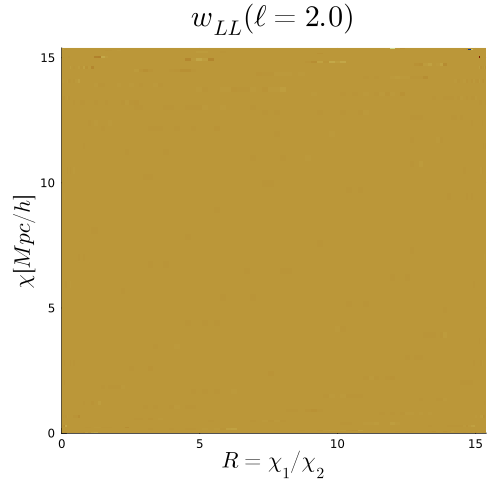

In [163]:
heatmap(k_grid_sorted, kp_grid_sorted, W_final_gal[50,:,:]./(maximum(W_final_gal[50,:,:])), size = (500,500), title=L"w_{LL}(ℓ=2.0)", 
    c =:roma , xlabel=L"R=\chi_1/\chi_2",ylabel=L"\chi[Mpc/h]", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)

In [135]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x, y))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));
# plot(k, power_spectrum.(k, 1000.0, 1000.0), 
#      label="Linear P(k)", 
#      xscale=:log10, 
#      yscale=:log10, 
#      title=L"$P(k)$ at $z=0$", titlefontsize=20,
#      xlabel=L"$k \; (h/\mathrm{Mpc})$", 
#      ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
#      labelfontsize=15)
# plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
#       label="Non-linear P(k)", 
#       xscale=:log10, 
#       yscale=:log10,
#       size=(800,600),
#       legendfontsize=10)

get_clencurt_grid produces the node of Clenshaw-Curtis mapped on [$k_{min}$, $k_{max}$]. \
get_clencurt_weights produces the corresponding quadrature weights scaled to the interval [-1,1]. \

In [136]:
Pk_grid = power_spectrum.(k_grid, kmin, kmax)
w_k = Blast.get_clencurt_weights(kmin, kmax, Nk)
weight_gal = w_k .* k_grid.^2 .* Pk_grid 
;

In [137]:
abstract type AbstractProbe end
struct Galaxy <: AbstractProbe end
struct Shear <: AbstractProbe end
factorial_frac(ℓ) = (ℓ + 2.0) * (ℓ + 1.0) * ℓ * (ℓ - 1.0)
get_ell_prefactor(::Galaxy, ::Galaxy, ℓ) = @. (2 / π) * ones(length(ℓ))
get_ell_prefactor(::Galaxy, ::Shear,  ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Galaxy, ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Shear,  ℓ) = @. (2 / π) * factorial_frac(ℓ)
pref_gg = get_ell_prefactor(Galaxy(), Galaxy(), ℓ)
pref_gg = reduce(vcat, pref_gg)
pref_gs = get_ell_prefactor(Galaxy(), Shear(), ℓ)
pref_gs = reduce(vcat, pref_gs)
pref_gg = reduce(vcat, pref_gg)
pref_ss = get_ell_prefactor(Shear(), Shear(), ℓ)
pref_ss = reduce(vcat, pref_ss);

In [138]:
println("SIZES")
println("weight_gal -> ", size(weight_gal))
println("W_final_gal -> ", size(W_final_gal))
println("pref_gg -> ", size(pref_gg), "\npref_ss -> ", size(pref_ss), "\npref_gs -> ", size(pref_gs))

SIZES
weight_gal -> (110,)
W_final_gal -> (100, 110, 90)
pref_gg -> (100,)
pref_ss -> (100,)
pref_gs -> (100,)


In [210]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(ℓ))
#@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp]
@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp] * kp_grid[kp] * kp_grid[kpp]
println("Size of S_l (kp, kpp) (gal-gal):  ", size(S_lkk_gg))
npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)
;

Size of S_l (kp, kpp) (gal-gal):  (90, 90, 100)


In [211]:
i = Nkp
j = Nkpp
k1 = kp_grid[i]
k2 = kpp_grid[j];

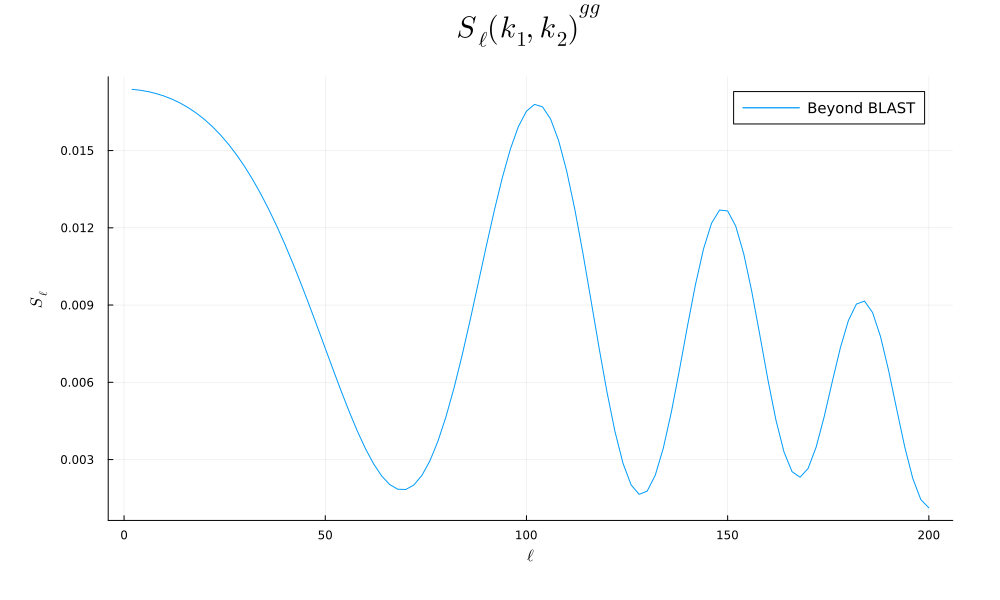

In [212]:
# plot
i = 10
j = 10
plot(ℓ, S_lkk_gg[i,j,:], label="Beyond BLAST", 
    xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg}",
    size=(1000, 600), titlefontsize=20, 
    legendfontsize=10, margin = 10mm)

In [213]:
# # plot
# i = 1
# j = 1
# p1 =  plot(ℓ, k1 * k2 * S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg} k_1 k_2")
# p2 =  plot(ℓ, S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg}")

# plot(p1, p2, layout = (1, 2), size=(2000, 600), titlefontsize=20, legendfontsize=10, margin = 10mm)

In [214]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_and_k1k2.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_29_131013/plots/Sl_plots/S_l_plot_gg_and_k1k2.png"

In [227]:
println("k")
ka = Nk
println(k_grid[ka])
kb = Nk - 5
println(k_grid[kb])
kc = Nk - 10
println(k_grid[kc])
kd = Nk - 30
println(k_grid[kd])
ke = Nk - Nk + 3
println(k_grid[ke])
##################
println("kp")
kpa = Nkp
println(k_grid[kpa])
kpb = Nkp - 5
println(k_grid[kpb])
kpc = Nkp - 10
println(k_grid[kpc])
kpd = Nkp - 30
println(k_grid[kpd])
kpe = Nkp - Nkp + 3
println(k_grid[kpe])
;

k
0.0003571428607137071
0.08009261916163979
0.3176459956935114
2.701063906439477
15.371839144928291
kp
1.2433371703648817
1.9122838120473356
2.701063906439477
6.697621222798133
15.371839144928291


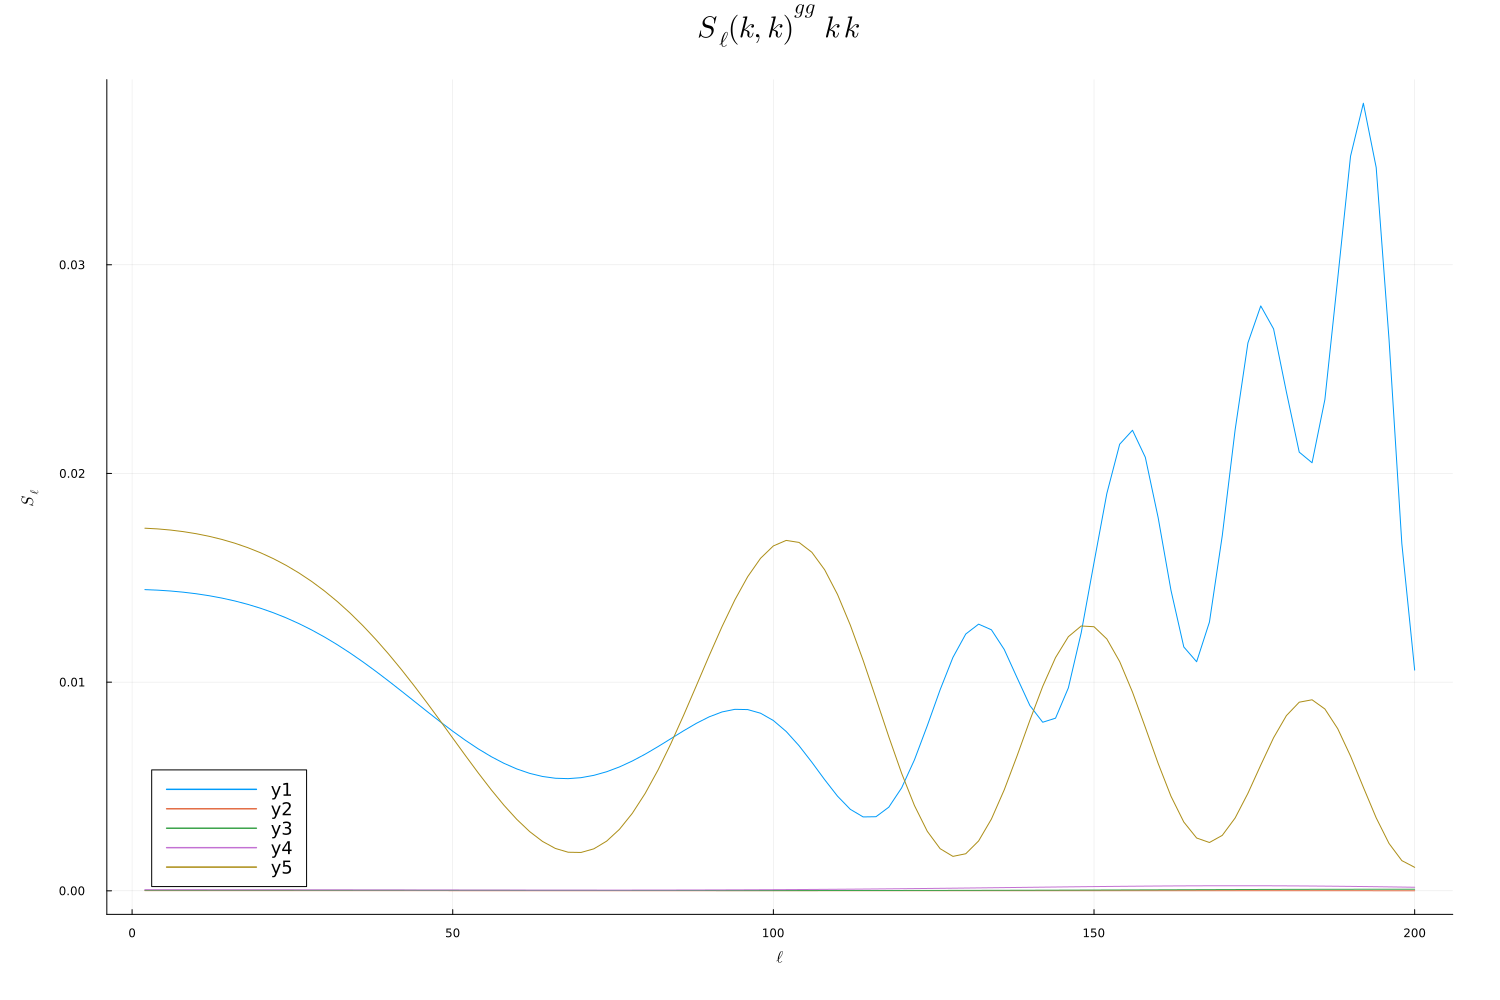

In [238]:
p = plot(ℓ, S_lkk_gg[4,4,:],
    #label="k = 0.000357 h/Mpc"
    )
plot!(p, ℓ, S_lkk_gg[70,70,:],
    #label="k = 0.004562 h/Mpc"
    )
plot!(p, ℓ, S_lkk_gg[50,50,:],
     #label="k = 0.017175 h/Mpc"
     )
plot!(p, ℓ, S_lkk_gg[30,30,:],
    #label="k = 0.151276 h/Mpc"
    )
plot!(p, ℓ, S_lkk_gg[10,10,:],
    #label="k = 15.3846 h/Mpc"
    )
plot!(p,
    xlabel=L"\ell",
    ylabel=L"S_\ell",
    size=(1500, 1000),
    title=L"S_\ell(k, k)^{gg} \ k\,k",
    titlefontsize=20,
    legendfontsize=12,
    margin=10mm)
plot!(p, legendposition=:bottomleft)

In [239]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_different_ks.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_29_131013/plots/Sl_plots/S_l_plot_gg_different_ks.png"

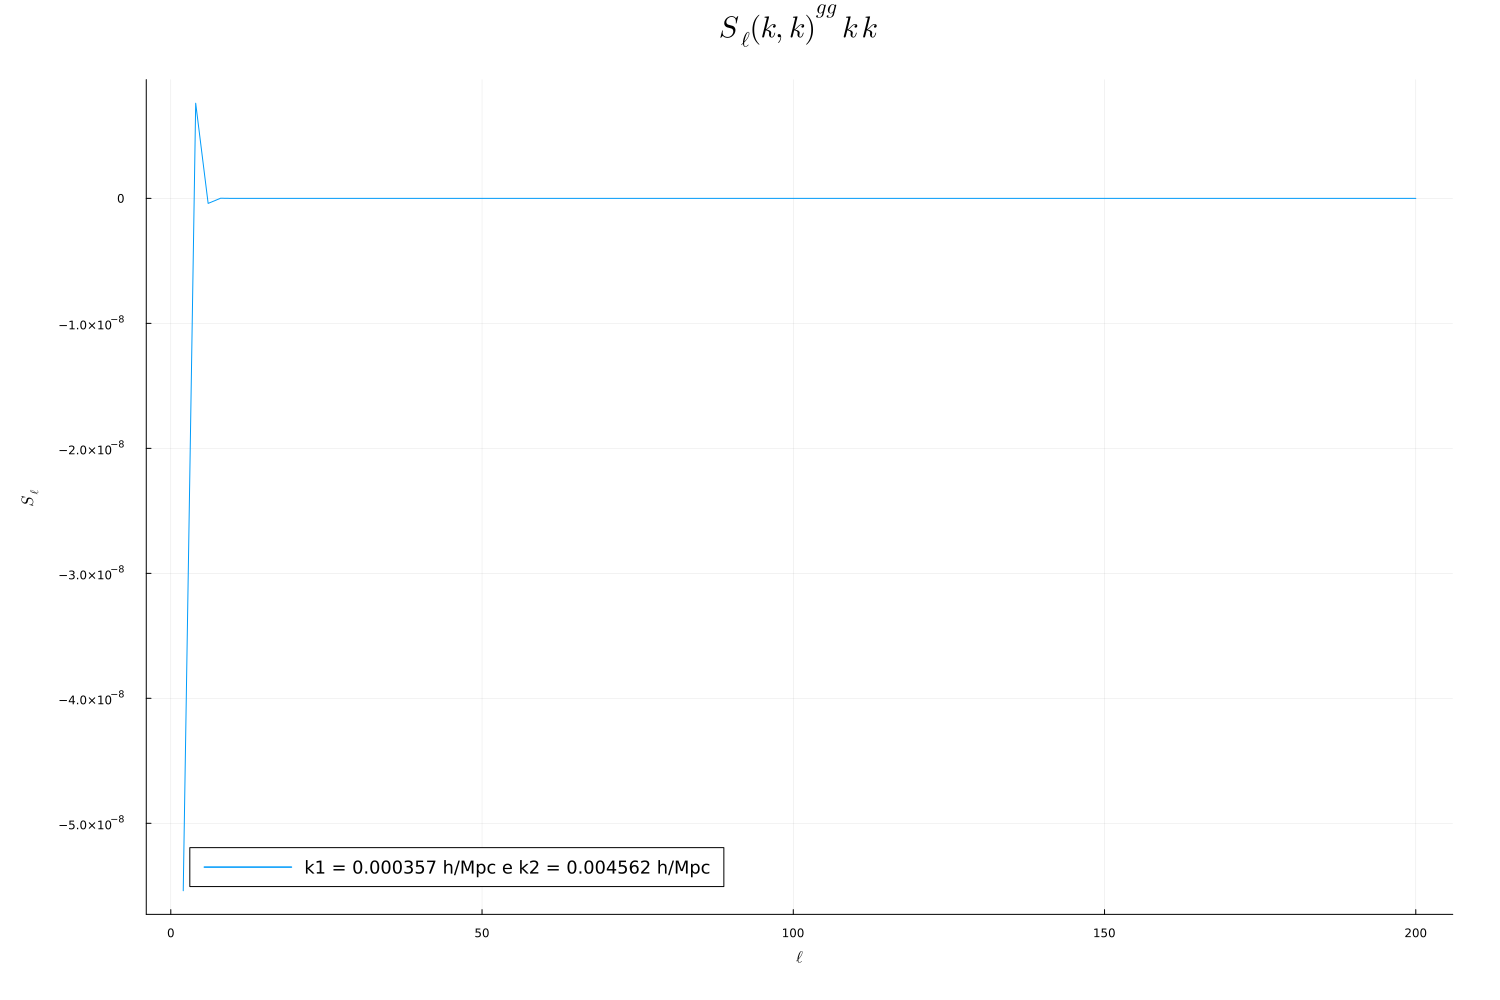

In [244]:
i = 1
j = 1

p = plot(ℓ, S_lkk_gg[5,90,:],
    label="k1 = 0.000357 h/Mpc e k2 = 0.004562 h/Mpc",
    xlabel=L"\ell",
    ylabel=L"S_\ell",
    title=L"S_\ell(k, k)^{gg} \, k\,k")
# plot!(p, ℓ, S_lkk_gg[50,70,:],
#     label="k1 = 0.004562 h/Mpc e k2 = 0.017175 h/Mpc")
# plot!(p, ℓ, S_lkk_gg[30,50,:],
#     label="k1 = 0.017175 h/Mpc e k2 = 0.151276 h/Mpc")
# plot!(p, ℓ, S_lkk_gg[10,30,:],
#     label="k1 = 0.000357 h/Mpc e k2 = 0.151276 h/Mpc")
# plot!(p, ℓ, S_lkk_gg[i,j,:],
#     label="k1 = 0.000357 h/Mpc e k2 = 15.3846 h/Mpc")
plot!(p,
    size=(1500, 1000),
    titlefontsize=20,
    legendfontsize=12,
    margin=10mm,
    legendposition=:bottomleft)

In [190]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_different_k_and_ks.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_29_131013/plots/Sl_plots/S_l_plot_gg_different_k_and_ks.png"

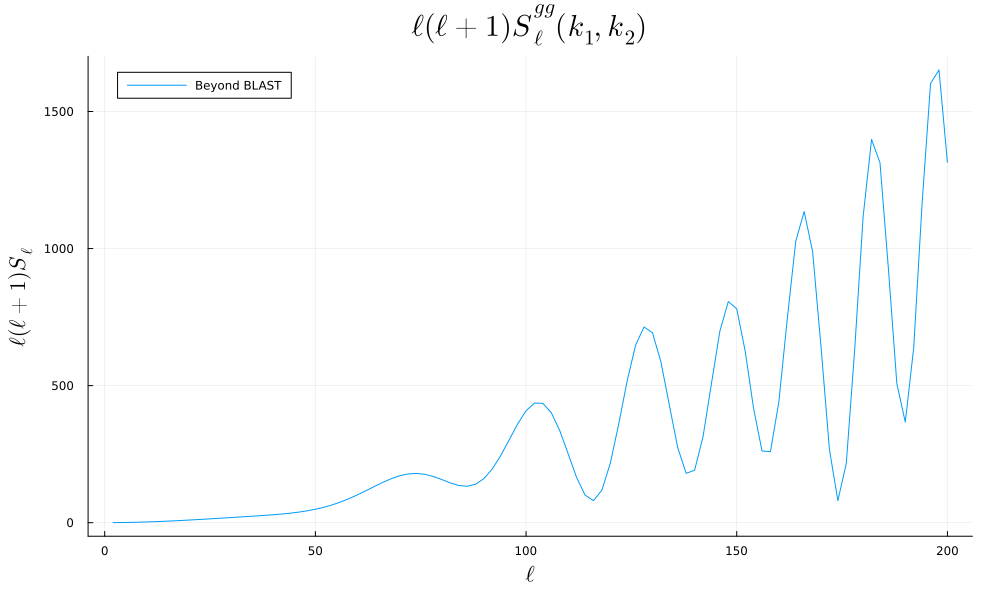

In [245]:
plot(
    ℓ,
    S_lkk_gg[1, 1, :] .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gg}(k_1,k_2)",
    markersize=4,
    size = (1000, 600),
    titlefontsize=20,
    labelfontsize=15,
    margin = 5mm
)

In [246]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_ll+1.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_29_131013/plots/Sl_plots/S_l_plot_ll+1.png"

In [249]:
heatmap(ℓ, log10.(sort(k_grid)), S_lkk_gg[1,:,:], ylabel=L"\log_{10}(k \; (h/\mathrm{Mpc}))", xlabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))

print device already activated


ArgumentError: ArgumentError: Length of x & y does not match the size of z.
Must be either `size(z) == (length(y), length(x))` (x & y define midpoints)
or `size(z) == (length(y)+1, length(x)+1))` (x & y define edges).


In [ ]:
heatmap(log10.(sort(k_grid)), log10.(sort(k_grid)), S_lkk_gg[:,:,1], ylabel=L"\log_{10}(k \; (h/\mathrm{Mpc}))", xlabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))

In [ ]:
#heatmap(k_grid, ℓ, S_lkk_gg[:,1,:], xlabel=L"k \; (h/\mathrm{Mpc})", ylabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))
#if i want it into log
heatmap(log10.(sort(k_grid)), ℓ, S_lkk_gg[:,1,:], xlabel=L"\log_{10}(\mathrm{k} \; (h/\mathrm{Mpc}))", ylabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))

In [ ]:
# S_lkk ha dimensioni (k1, k2, ℓ) = [96,96,100]
# k_grid deve avere lunghezza 96
# ℓ deve avere lunghezza 100

diagS = [diag(@view S_lkk_gg[:, :, i]) for i in 1:size(S_lkk_gg, 3)]
print(size(diagS))
nshow = 8
idx = round.(Int, range(1, size(S_lkk_gg, 3), length=nshow))

p = plot(
    xscale = :log10,
    xlabel = L"k \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell(k,k)",
    title  = L"S_\ell^{gg}(k,k)\ \mathrm{for\ different}\ \ell values",
    legend = :topright,
    framestyle = :box,
    grid = true,
    lw = 2,
    size = (1000, 600),
    titlefontsize = 20,
    legendfontsize = 12,
    margin = 10mm,
    legendposition = :outertopright
)

for i in idx
    plot!(p, k_grid, diagS[i], label = "ℓ=$(i)")

end

display(p)

In [ ]:
params_run = Dict(
    "x_min" => x_min,
    "x_max" => x_max,
    "n_chi" => n_chi,
    "zmin" => zmin,
    "zmax" => zmax,
    "kmin" => kmin,
    "kmax" => kmax,
    "n_cheb" => n_cheb,
    "N" => N,
    "ℓ" => length(ℓ)
)

open(joinpath(output_dir, "config.json"), "w") do dictio
    JSON.print(dictio, params_run, 4)
end

println("Data brought to safety in folder: ", output_dir)

---

#### Are the two methods to compute $W$ the same?

In [ ]:
W_tilde_slow = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_slow.npy");
W_tilde_fast = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_fast.npy");
rel_difference = maximum(abs.(W_tilde_fast .- W_tilde_slow)) / maximum(abs.(W_tilde_fast))
println(abs.(minimum(W_tilde_fast)))
println(abs.(minimum(W_tilde_slow)))
println(abs.(maximum(W_tilde_fast)))
println(abs.(maximum(W_tilde_slow)))